# KAN-CDSCO2004U  Machine Learning and Deep Learning

## Lab 5 — Dimensionality Reduction & Random Forests
**Estimated time: 1 hour**

### Learning Objectives
By the end of this lab, you will be able to:
- Understand why **feature standardization** is essential before applying PCA
- Apply **PCA** for dimensionality reduction and visualize results in 2D
- Analyze **explained variance** and choose the right number of components
- Train a **Random Forest** classifier on the MNIST digits dataset
- Tune hyperparameters with **GridSearchCV** and analyze **feature importance**
- Evaluate models with **OOB score**, **classification report**, and **confusion matrix**

**How to work through this notebook:**
- 🏃 **RUN** cells = Just execute the code to see the output
- ✏️ **TODO** cells = Write your own code or answer questions
- 📖 **READ** cells = Explanations to help you understand the concepts

---
## Setup

🏃 **RUN** the cell below to import all libraries needed for this lab.

In [1]:
# Import needed libraries
# Author: Luca Gudi (lgg.digi@cbs.dk)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.datasets import load_wine, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

# Display options
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

---
# Part A: Principal Component Analysis (PCA)

In this part, you will reduce the dimensionality of the **Wine** dataset (13 features → 2 components) using **Principal Component Analysis**.

---
## 1. Load and Explore the Data

📖 **READ**: The **Wine** dataset contains the results of a chemical analysis of wines grown in the same region in Italy, derived from three different cultivars. It includes:
- **178 samples** belonging to **3 classes** (cultivar 1, 2, 3)
- **13 numerical features** (alcohol, malic acid, ash, alkalinity, magnesium, phenols, flavanoids, etc.)

With 13 features, the data is difficult to visualize directly. PCA will help us project this high-dimensional data into 2D while preserving as much information as possible.

🏃 **RUN** the cells below to load and explore the data.

In [2]:
# Load the Wine dataset
wine = load_wine()

X = wine.data
y = wine.target
target_names = wine.target_names
feature_names = wine.feature_names

print(f"Dataset shape:   {X.shape}  →  {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes:         {target_names}")
print(f"Features:        {list(feature_names)}")

Dataset shape:   (178, 13)  →  178 samples, 13 features
Classes:         ['class_0' 'class_1' 'class_2']
Features:        ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [3]:
# Quick look at the feature ranges
df = pd.DataFrame(X, columns=feature_names)
df.describe().round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


---
## 2. Standardize the Features

📖 **READ**:
PCA identifies directions of **maximum variance** in the data. If features have very different scales (e.g., `proline` ranges from 278 to 1,680, while `ash` ranges from 1.36 to 3.23), features with larger magnitudes will dominate the principal components — not because they carry more information, but simply because they have bigger numbers.

**Standardization** transforms each feature to have:
- **Mean = 0** (centering)
- **Standard deviation = 1** (scaling)

This ensures that PCA treats all features equally and finds directions of true variance, not just scale differences.

✏️ **TODO**: Use `StandardScaler` to standardize the feature matrix `X`. Print the mean and standard deviation of the first feature before and after standardization to verify.

*Hint: Use `scaler.fit_transform(X)` to standardize in one step.*

In [4]:
# TODO: Standardize the features and verify the result
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Before standardization — Feature 0 ('{feature_names[0]}'):")
print(f"  Mean: {X[:, 0].mean():.2f},  Std: {X[:, 0].std():.2f}")
print(f"\nAfter standardization  — Feature 0 ('{feature_names[0]}'):")
print(f"  Mean: {X_scaled[:, 0].mean():.2f},  Std: {X_scaled[:, 0].std():.2f}")

Before standardization — Feature 0 ('alcohol'):
  Mean: 13.00,  Std: 0.81

After standardization  — Feature 0 ('alcohol'):
  Mean: 0.00,  Std: 1.00


---
## 3. Apply PCA

📖 **READ**:
PCA works in two steps:
1. **Fit**: Learn the principal components from the data (find the directions of maximum variance)
2. **Transform**: Project the data onto the new axes (principal components)

We'll reduce from **13 features → 2 components** so we can visualize the data in 2D.

✏️ **TODO**: Create a PCA model with `n_components=2`, fit it to the standardized data, and transform the data. Print the shape of the transformed data.

*Hint: Like StandardScaler, PCA has a `fit_transform()` method.*

In [5]:
# TODO: Apply PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Original shape:    {X_scaled.shape}")
print(f"Transformed shape: {X_pca.shape}")

Original shape:    (178, 13)
Transformed shape: (178, 2)


/Users/lucagudi/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/lucagudi/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/lucagudi/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


---
## 4. Analyze Explained Variance

📖 **READ**:
Each principal component captures a certain percentage of the total variance in the data. The **explained variance ratio** tells us how much information each component retains.

- **PC1** captures the most variance (the most informative direction)
- **PC2** captures the second most, and so on
- Together, the first few PCs often capture the majority of the total variance

✏️ **TODO**: Print the explained variance ratio for each component and their cumulative sum. What percentage of the total variance do the first 2 components explain together?

*Hint: Use `pca.explained_variance_ratio_`*

In [6]:
# TODO: Print explained variance for each component and the total
print("Explained variance ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.1f}%)")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.1f}%)")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.1f}%")

Explained variance ratio:
  PC1: 0.3620 (36.2%)
  PC2: 0.1921 (19.2%)
  Total: 55.4%


---
## 5. Visualize the PCA Projection

📖 **READ**:
Now that we've reduced the 13-dimensional data to 2D, we can create a scatter plot. Each point represents a wine sample, and we color them by their class (cultivar) to see how well PCA separates the groups.

✏️ **TODO**: Create a scatter plot of the PCA-transformed data. Color each class differently, add a legend with class names, axis labels ("PC1" and "PC2"), and a title.

*Hint: Loop over classes using `for i, name in enumerate(target_names)` and plot `X_pca[y == i, 0]` vs `X_pca[y == i, 1]`.*

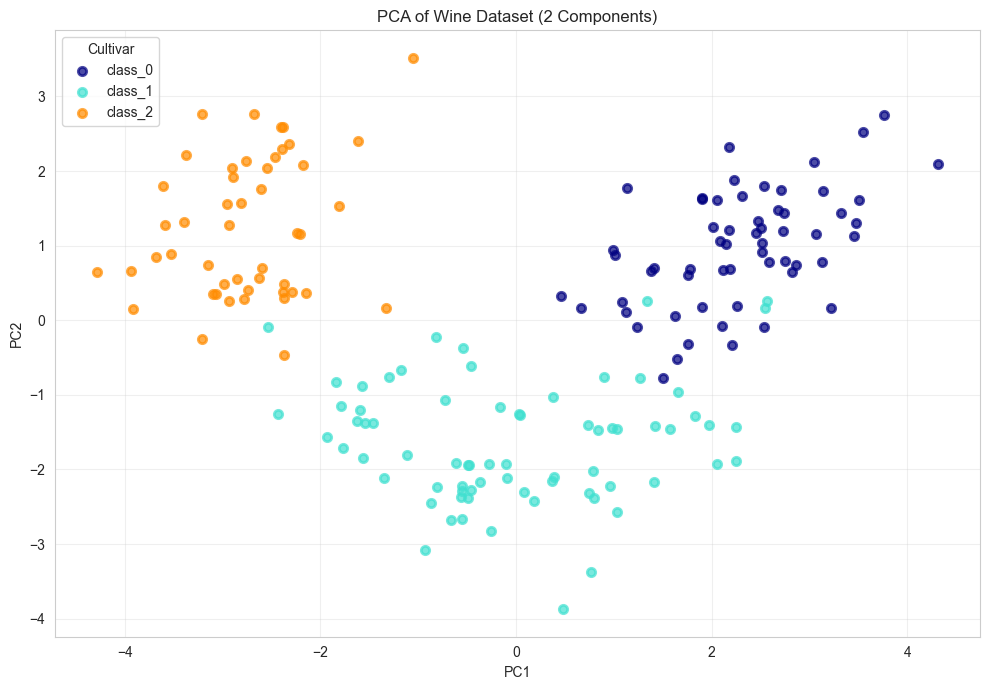

In [7]:
# TODO: Create a 2D scatter plot of the PCA projection
colors = ['navy', 'turquoise', 'darkorange']

plt.figure(figsize=(10, 7))
for i, (name, color) in enumerate(zip(target_names, colors)):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1],
                color=color, alpha=0.7, lw=2, label=name)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Wine Dataset (2 Components)")
plt.legend(loc='best', title='Cultivar')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Choosing the Right Number of Components

📖 **READ**:
In practice, you often need to decide **how many components to keep**. A common approach is to plot the **cumulative explained variance** as a function of the number of components and look for an "elbow" — the point where adding more components provides diminishing returns.

A typical rule of thumb is to keep enough components to explain **90–95%** of the total variance.

✏️ **TODO**: Fit a new PCA model with **all 13 components** (don't specify `n_components`). Then plot a bar chart of individual explained variance per component and a line plot of cumulative explained variance. Add a horizontal dashed line at 90% and 95%.

*Hint: Use `np.cumsum(pca_full.explained_variance_ratio_)` for the cumulative sum.*

/Users/lucagudi/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/lucagudi/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/lucagudi/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


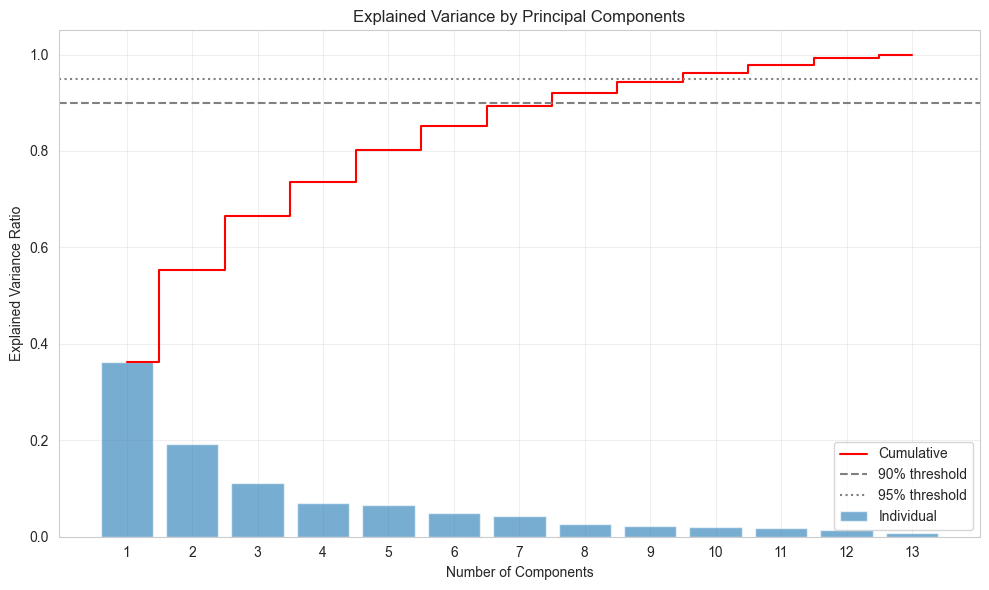


Components needed for 90% variance: 8
Components needed for 95% variance: 10


In [8]:
# TODO: Create a cumulative explained variance plot
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_, alpha=0.6, label='Individual')
plt.step(range(1, len(cumulative_var) + 1), cumulative_var, where='mid',
         color='red', label='Cumulative')
plt.axhline(y=0.90, color='gray', linestyle='--', label='90% threshold')
plt.axhline(y=0.95, color='gray', linestyle=':', label='95% threshold')
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Components")
plt.xticks(range(1, 14))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nComponents needed for 90% variance: {np.argmax(cumulative_var >= 0.90) + 1}")
print(f"Components needed for 95% variance: {np.argmax(cumulative_var >= 0.95) + 1}")

### ✏️ TODO: Answer the following questions

**Q1: Why is standardization important before applying PCA? What would happen if we skipped it?**

Your answer: PCA finds directions of maximum variance. Without standardization, features with larger scales (e.g., `proline` ranging 278–1,680) would dominate the principal components, regardless of their actual importance. Standardization ensures all features contribute equally to the variance analysis.

**Q2: How many components would you need to explain at least 90% of the variance? What about 95%?**

Your answer: Based on the cumulative variance plot, approximately 8 components are needed for 90% and about 10 components for 95% of the total variance.

**Q3: What are the main limitations of PCA?**

| | Limitation | Explanation |
| :--- | :--- | :--- |
| **1** | Assumes linearity | PCA only captures linear relationships between features |
| **2** | Sensitive to scaling | Features must be standardized; otherwise large-scale features dominate |
| **3** | Components are hard to interpret | PCs are linear combinations of all original features, losing interpretability |

---
# Part B: Random Forest Classification

In this part, you will classify handwritten digits using **Random Forests**, a powerful ensemble method that combines many Decision Trees to produce robust predictions.

---
## 7. Load and Explore the Data

📖 **READ**: The **MNIST digits** dataset (sklearn's built-in version) contains:
- **1,797 samples** of handwritten digits (0–9)
- Each image is **8×8 pixels**, flattened to a **64-dimensional** feature vector
- Each pixel value ranges from **0** (white) to **16** (black)

This is a classic multi-class classification problem with 10 classes.

🏃 **RUN** the cells below to load and visualize the data.

In [9]:
# Load the digits dataset
digits = load_digits()

X = digits.data
y = digits.target

print(f"Dataset shape: {X.shape}  →  {X.shape[0]} samples, {X.shape[1]} features")
print(f"Target classes: {np.unique(y)} ({len(np.unique(y))} classes)")
print(f"Samples per class: {np.bincount(y)}")

Dataset shape: (1797, 64)  →  1797 samples, 64 features
Target classes: [0 1 2 3 4 5 6 7 8 9] (10 classes)
Samples per class: [178 182 177 183 181 182 181 179 174 180]


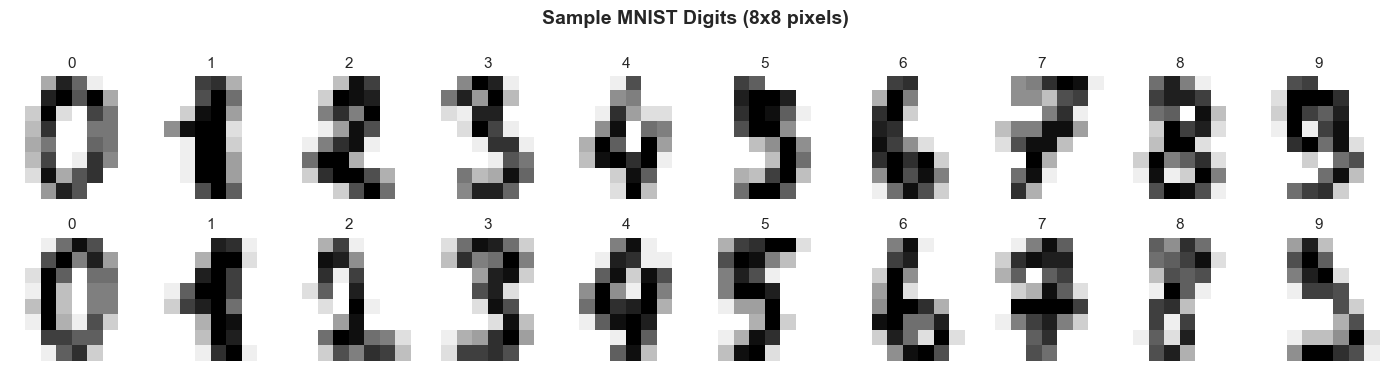

In [10]:
# Visualize the first 20 digits
fig, axes = plt.subplots(2, 10, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray_r', interpolation='nearest')
    ax.set_title(f"{digits.target[i]}", fontsize=11)
    ax.axis('off')
plt.suptitle("Sample MNIST Digits (8x8 pixels)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Train/Test Split

📖 **READ**: We split the data into **training** and **test** sets. The training set is used to build the model, and the test set evaluates how well it generalizes to unseen data.

✏️ **TODO**: Split `X` and `y` into training and test sets (80/20 split, `random_state=42`). Print the number of samples in each set.

In [11]:
# TODO: Split the dataset and print the sizes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 1437 samples
Test set:     360 samples


---
## 9. Basic Random Forest Classification

📖 **READ**:
A **Random Forest** is an ensemble of Decision Trees, each trained on a **bootstrap sample** (random sample with replacement) of the training data. At each split, only a **random subset of features** is considered. This double randomness makes the individual trees diverse, and their combined prediction (majority vote) is usually much better than any single tree.

Key hyperparameters:
- `n_estimators` — number of trees in the forest (more trees = more stable, but slower)
- `max_depth` — maximum depth of each tree (controls overfitting)
- `max_features` — number of features to consider at each split (controls diversity)
- `random_state` — for reproducibility

### 9.1 Train a Basic Model

✏️ **TODO**: Create a `RandomForestClassifier` with `n_estimators=100` and `random_state=42`. Evaluate it using **5-fold cross-validation** on the training set. Print the mean accuracy and standard deviation.

*Hint: Use `cross_val_score(model, X_train, y_train, cv=5)`.*

In [12]:
# TODO: Create a Random Forest and evaluate with cross-validation
rf = RandomForestClassifier(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_train, y_train, cv=5)

print(f"Cross-validation scores: {scores}")
print(f"Mean accuracy:           {scores.mean():.4f}")
print(f"Standard deviation:      {scores.std():.4f}")

Cross-validation scores: [0.97916667 0.96875    0.96167247 0.98606272 0.96515679]
Mean accuracy:           0.9722
Standard deviation:      0.0091


### 9.2 Fit and Predict

✏️ **TODO**: Fit the Random Forest on the full training set, make predictions on the test set, and print the test accuracy.

*Hint: Use `metrics.accuracy_score(y_test, y_pred)` for accuracy.*

In [13]:
# TODO: Fit, predict, and print accuracy
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f"Test accuracy: {metrics.accuracy_score(y_test, y_pred):.4f}")

Test accuracy: 0.9722


---
## 10. Hyperparameter Tuning with GridSearchCV

📖 **READ**:
Random Forests have several important hyperparameters that affect performance:

| Hyperparameter | What it controls | Too low → | Too high → |
| :--- | :--- | :--- | :--- |
| `n_estimators` | Number of trees | Unstable predictions | Slower training |
| `max_depth` | Tree depth limit | Underfitting | Overfitting |
| `max_features` | Features per split | More diversity, less accuracy per tree | Less diversity, risk of overfitting |

**GridSearchCV** will try all combinations and find the best ones using cross-validation.

✏️ **TODO**: Use `GridSearchCV` to search over the following parameter grid with 5-fold CV:
- `n_estimators`: [100, 200]
- `max_depth`: [10, 20, None]
- `max_features`: ['sqrt', 'log2']

Print the best parameters and best CV score.

*Hint: Create a `param_grid` dictionary and pass it to `GridSearchCV()`. Use `n_jobs=-1` to speed things up.*

In [14]:
# TODO: Define the parameter grid and run GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, n_jobs=-1, return_train_score=True
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score:   {grid_search.best_score_:.4f}")

Best parameters: {'max_depth': 20, 'max_features': 'log2', 'n_estimators': 200}
Best CV score:   0.9756


---
## 11. Feature Importance

📖 **READ**:
One major advantage of Random Forests is that they provide **feature importance** scores. These tell you which features contribute most to the classification.

For the MNIST digits, each feature corresponds to a **pixel position** in the 8×8 image. By reshaping the importance scores back into an 8×8 grid, we can visualize which pixels are most useful for digit recognition.

Feature importance is computed based on the **total reduction in impurity** (Gini index) that each feature contributes across all trees in the forest.

### 11.1 Extract Feature Importance

✏️ **TODO**: Using the best model from GridSearchCV (or your trained model), extract and print the top 10 most important features (pixel positions).

*Hint: Use `model.feature_importances_` and `np.argsort()` to sort them.*

In [15]:
# TODO: Extract and display the top 10 most important features
best_model = grid_search.best_estimator_

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Top 10 most important features (pixel positions):")
for rank in range(10):
    print(f"  {rank + 1}. Pixel {indices[rank]:2d} — importance: {importances[indices[rank]]:.4f}")

Top 10 most important features (pixel positions):
  1. Pixel 21 — importance: 0.0441
  2. Pixel 43 — importance: 0.0406
  3. Pixel 26 — importance: 0.0391
  4. Pixel 36 — importance: 0.0362
  5. Pixel 42 — importance: 0.0345
  6. Pixel 33 — importance: 0.0316
  7. Pixel 61 — importance: 0.0316
  8. Pixel 20 — importance: 0.0303
  9. Pixel 30 — importance: 0.0302
  10. Pixel 28 — importance: 0.0295


### 11.2 Visualize Feature Importance as a Heatmap

✏️ **TODO**: Reshape the feature importance array into an 8×8 grid and display it as a heatmap. This shows which pixel positions the model considers most informative.

*Hint: Use `model.feature_importances_.reshape(8, 8)` and `plt.imshow()`.*

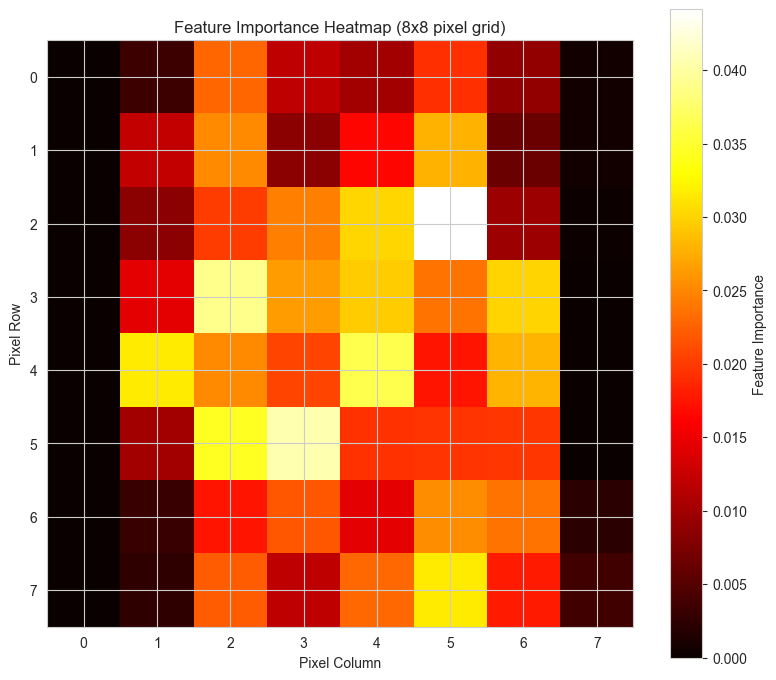

In [16]:
# TODO: Visualize feature importance as a heatmap
importance_map = best_model.feature_importances_.reshape(8, 8)

plt.figure(figsize=(8, 7))
plt.imshow(importance_map, cmap='hot', interpolation='nearest')
plt.colorbar(label='Feature Importance')
plt.title("Feature Importance Heatmap (8x8 pixel grid)")
plt.xlabel("Pixel Column")
plt.ylabel("Pixel Row")
plt.tight_layout()
plt.show()

---
## 12. Out-of-Bag (OOB) Score

📖 **READ**:
In bagging, each tree is trained on a **bootstrap sample** (~63.2% of the data). The remaining **~36.8%** of samples not used for training a given tree are called **out-of-bag (OOB)** samples.

The **OOB score** is computed by predicting each sample using only the trees that did **not** include that sample in their training set. This gives you a built-in validation score without needing a separate validation set!

✏️ **TODO**: Train a new `RandomForestClassifier` with `oob_score=True`, using `n_estimators=200` and `random_state=42`. Print the OOB score and compare it to the cross-validation score.

*Hint: After fitting, access `model.oob_score_`.*

In [17]:
# TODO: Train a model with OOB scoring enabled
rf_oob = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    random_state=42
)

rf_oob.fit(X_train, y_train)

print(f"OOB score:              {rf_oob.oob_score_:.4f}")
print(f"Best CV score (for ref): {grid_search.best_score_:.4f}")

OOB score:              0.9701
Best CV score (for ref): 0.9756


---
## 13. Final Evaluation

✏️ **TODO**: Using the best model, predict on the test set and display:
1. The **classification report** (precision, recall, F1-score per digit)
2. The **confusion matrix** as a heatmap plot

In [18]:
# TODO: Print the classification report
best_pred = grid_search.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, best_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       1.00      1.00      1.00        33
           3       1.00      0.97      0.99        34
           4       1.00      1.00      1.00        46
           5       0.94      0.98      0.96        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       1.00      0.93      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



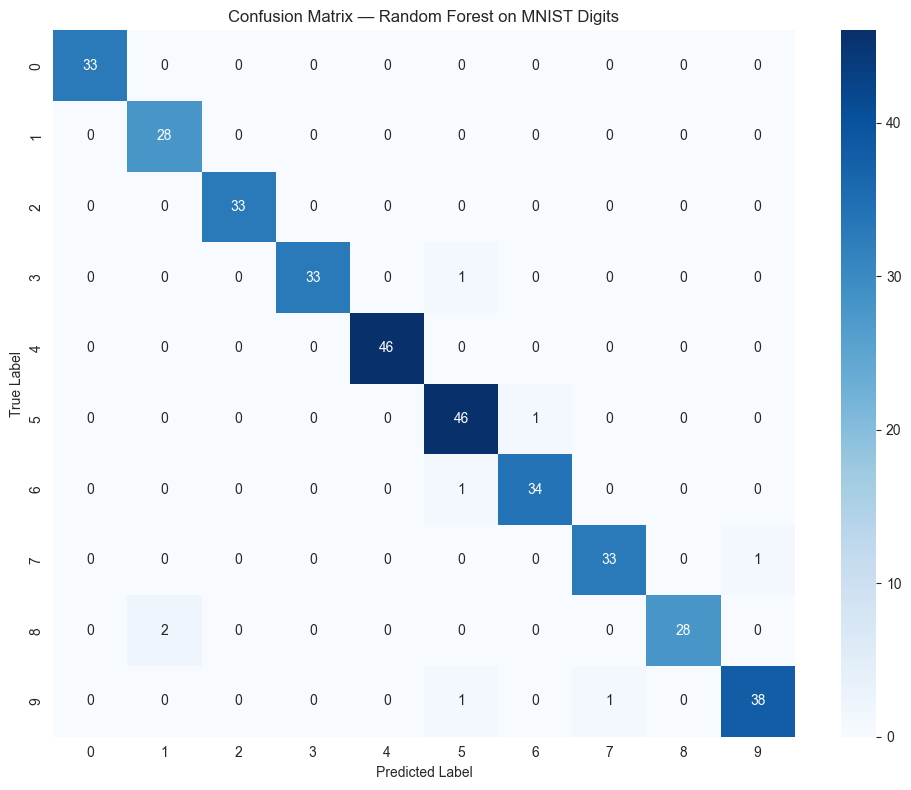

In [19]:
# TODO: Plot the confusion matrix as a heatmap
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Random Forest on MNIST Digits")
plt.tight_layout()
plt.show()

### ✏️ TODO: Answer the following questions

**Q4: How does a Random Forest reduce overfitting compared to a single Decision Tree?**

Your answer: Random Forests reduce overfitting through two mechanisms: (1) **Bagging** — each tree is trained on a bootstrap sample, so no single tree sees all the data, and averaging many trees reduces variance. (2) **Feature randomness** — at each split, only a random subset of features is considered, making the trees diverse and less correlated.

**Q5: What does the feature importance heatmap tell us? Which areas of the digit images are most informative?**

Your answer: The heatmap shows that the center pixels of the 8×8 grid are the most important for digit classification. Edge and corner pixels have low importance because they are usually blank (white) for all digits. The central region is where the distinguishing strokes of different digits appear.

**Q6: Compare the main properties of Decision Trees and Random Forests:**

| Property | Decision Tree | Random Forest |
| :--- | :--- | :--- |
| **Bias/Variance** | Low bias, high variance | Low bias, lower variance |
| **Overfitting risk** | High (can memorize training data) | Lower (averaging reduces overfitting) |
| **Interpretability** | High (can visualize the tree) | Lower (many trees, harder to inspect) |
| **Training speed** | Fast (single tree) | Slower (must train many trees) |
| **Prediction accuracy** | Moderate | Generally higher |

---
## Summary

In this lab, you learned how to:

| Section | Technique | Python Code / sklearn Class |
| :--- | :--- | :--- |
| **2. Standardization** | Scale features to zero mean, unit variance | `StandardScaler().fit_transform(X)` |
| **3. Apply PCA** | Reduce dimensions from 13 → 2 | `PCA(n_components=2).fit_transform(X_scaled)` |
| **4. Explained Variance** | Assess information retained per component | `pca.explained_variance_ratio_` |
| **5. PCA Visualization** | Scatter plot of 2D PCA projection | `plt.scatter()` with class coloring |
| **6. Choosing Components** | Cumulative variance plot | `np.cumsum(pca.explained_variance_ratio_)` |
| **8. Train/Test Split** | Splitting data for evaluation | `train_test_split(X, y, test_size=0.2)` |
| **9. Basic RF** | Train a Random Forest classifier | `RandomForestClassifier(n_estimators=100)` |
| **9.1 Cross-Validation** | Evaluate model stability | `cross_val_score(model, X, y, cv=5)` |
| **10. Grid Search** | Tune multiple hyperparameters | `GridSearchCV(model, param_grid, cv=5)` |
| **11. Feature Importance** | Identify most informative features | `model.feature_importances_` |
| **12. OOB Score** | Built-in validation from bagging | `RandomForestClassifier(oob_score=True)` |
| **13. Evaluation** | Assess predictions in detail | `classification_report()`, `confusion_matrix()` |

**Key takeaways:**
- **PCA** is an unsupervised linear technique that projects data onto orthogonal axes of maximum variance
- **Standardization** is critical before PCA, features with larger scales would otherwise dominate
- A **cumulative variance plot** helps you decide how many components to retain (aim for 90–95%)
- **Random Forests** combine many Decision Trees using **bagging** and **feature randomness** to reduce overfitting
- **GridSearchCV** is essential for finding the best combination of hyperparameters
- **Feature importance** reveals which input features drive the model's predictions
- The **OOB score** provides a free validation metric without needing a separate validation set